In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")
# Define the subset of emotion classes you want to keep
selected_classes = ["anger","romantic", "joy","sadness"]

# Filter the DataFrame to include only those classes
df_subset = df[df["final_emotion"].isin(selected_classes)]


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert lyrics to TF-IDF matrix
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
X_tfidf = vectorizer.fit_transform(df_subset["cleaned_lyrics"])
# X_tfidf = vectorizer.fit_transform(df["cleaned_lyrics"])

In [42]:
from sklearn.decomposition import TruncatedSVD

# Apply LSA
lsa = TruncatedSVD(n_components=300, random_state=42)
X_lsa = lsa.fit_transform(X_tfidf)


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_lsa, df_subset["final_emotion"], test_size=0.2, random_state=42, stratify=df_subset["final_emotion"]
    # X_lsa, df["final_emotion"], test_size=0.2, random_state=42, stratify=df["final_emotion"]
)

# Train SVM
svm = LinearSVC()
svm.fit(X_train, y_train)

# Evaluate
y_pred = svm.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.57      0.59      0.58      1515
         joy       0.40      0.35      0.37      1426
    romantic       0.54      0.52      0.53      1661
     sadness       0.41      0.45      0.43      1483

    accuracy                           0.48      6085
   macro avg       0.48      0.48      0.48      6085
weighted avg       0.48      0.48      0.48      6085

[[899 200 169 247]
 [192 501 337 396]
 [241 242 869 309]
 [253 321 247 662]]


              precision    recall  f1-score   support

       anger       0.57      0.59      0.58      1515
         joy       0.40      0.35      0.37      1426
    romantic       0.54      0.52      0.53      1661
     sadness       0.41      0.45      0.43      1483

    accuracy                           0.48      6085
   macro avg       0.48      0.48      0.48      6085
weighted avg       0.48      0.48      0.48      6085

Confusion Matrix:
 [[899 200 169 247]
 [192 501 337 396]
 [241 242 869 309]
 [253 321 247 662]]


<Figure size 1200x800 with 0 Axes>

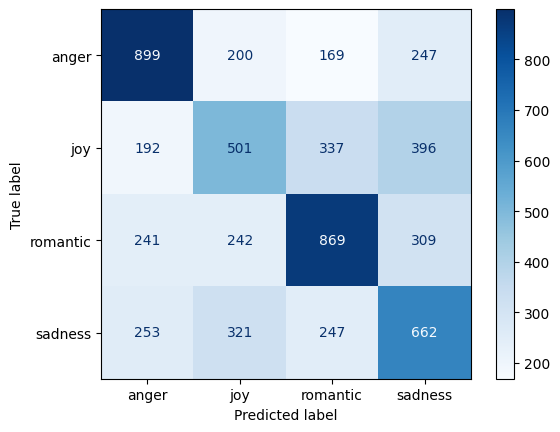

In [45]:
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
plt.figure(figsize=(12, 8))  # adjust width x height in inches

# Train model


# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap='Blues', values_format='d')
